<a href="https://colab.research.google.com/github/Ranesshtallapelly/Data-analysis-python/blob/main/DaupLabExam2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
print(f"First 5 daily speeding vehicles: {daily_speeding_vehicles[:5]}")
print(f"First 5 daily detected vehicles: {daily_detected_vehicles[:5]}")

First 5 daily speeding vehicles: [75, 77, 98, 73, 85]
First 5 daily detected vehicles: [63, 69, 81, 58, 73]


In [2]:
p = 0.85
lambda_poisson = 2
num_sensors = 40
num_days = 5000

print(f"Probability of detection (p): {p}")
print(f"Average speeding vehicles per sensor per day (lambda_poisson): {lambda_poisson}")
print(f"Number of sensors (num_sensors): {num_sensors}")
print(f"Number of simulation days (num_days): {num_days}")

Probability of detection (p): 0.85
Average speeding vehicles per sensor per day (lambda_poisson): 2
Number of sensors (num_sensors): 40
Number of simulation days (num_days): 5000


In [4]:
import numpy as np

daily_speeding_vehicles = []
daily_detected_vehicles = []

for day in range(num_days):
    total_speeding_today = 0
    total_detected_today = 0
    for sensor in range(num_sensors):
        # Simulate speeding vehicles using Poisson distribution
        speeding_vehicles_per_sensor = np.random.poisson(lambda_poisson)

        # Simulate detected vehicles using Binomial distribution
        detected_vehicles_per_sensor = np.random.binomial(speeding_vehicles_per_sensor, p)

        total_speeding_today += speeding_vehicles_per_sensor
        total_detected_today += detected_vehicles_per_sensor

    daily_speeding_vehicles.append(total_speeding_today)
    daily_detected_vehicles.append(total_detected_today)

print(f"First 5 daily speeding vehicles: {daily_speeding_vehicles[:5]}")
print(f"Total length of daily_speeding_vehicles: {len(daily_speeding_vehicles)}")
print(f"First 5 daily detected vehicles: {daily_detected_vehicles[:5]}")
print(f"Total length of daily_detected_vehicles: {len(daily_detected_vehicles)}")

First 5 daily speeding vehicles: [75, 77, 98, 73, 85]
Total length of daily_speeding_vehicles: 5000
First 5 daily detected vehicles: [63, 69, 81, 58, 73]
Total length of daily_detected_vehicles: 5000


In [5]:
import numpy as np

# 1. Convert lists to NumPy arrays
daily_detected_vehicles_arr = np.array(daily_detected_vehicles)
daily_speeding_vehicles_arr = np.array(daily_speeding_vehicles)

# 2. Calculate the probability that total detections are less than 750
prob_detections_less_750 = np.mean(daily_detected_vehicles_arr < 750)

# 3. Compute the expected detection rate (average daily detections)
expected_detection_rate = np.mean(daily_detected_vehicles_arr)

# 4. Calculate total number of detected vehicles over all simulation days
total_detected = np.sum(daily_detected_vehicles_arr)

# 5. Calculate total number of speeding vehicles over all simulation days
total_speeding = np.sum(daily_speeding_vehicles_arr)

# 6. Calculate total number of undetected vehicles over all simulation days
total_undetected = total_speeding - total_detected

# 7. Compute the ratio of detected to undetected violations, handling division by zero
if total_undetected > 0:
    ratio_detected_to_undetected = total_detected / total_undetected
else:
    ratio_detected_to_undetected = float('inf') # Or handle as per domain knowledge

# 8. Print the calculated values
print(f"Probability of total detections less than 750: {prob_detections_less_750:.4f}")
print(f"Expected detection rate (average daily detections): {expected_detection_rate:.2f}")
print(f"Ratio of detected to undetected violations: {ratio_detected_to_undetected:.2f}")

Probability of total detections less than 750: 1.0000
Expected detection rate (average daily detections): 68.02
Ratio of detected to undetected violations: 5.64


In [6]:
import numpy as np

# 1. Calculate the overall detection proportion
total_detected_all_days = np.sum(daily_detected_vehicles_arr)
total_speeding_all_days = np.sum(daily_speeding_vehicles_arr)

# Handle division by zero if total_speeding_all_days is 0, though unlikely with current parameters
if total_speeding_all_days > 0:
    overall_detection_proportion = total_detected_all_days / total_speeding_all_days
else:
    overall_detection_proportion = 0 # Or handle as a special case

print(f"Overall detection proportion: {overall_detection_proportion:.4f}")

# 2. Define the number of bootstrap samples
n_bootstrap_samples = 10000

# 3. Initialize an empty list
bootstrap_detection_proportions = []

# 4. Loop n_bootstrap_samples times
for _ in range(n_bootstrap_samples):
    # a. Randomly resample (with replacement) num_days indices
    resampled_indices = np.random.choice(num_days, num_days, replace=True)

    # b. Use these resampled indices to select corresponding daily detected and speeding vehicle counts
    bootstrap_detected = daily_detected_vehicles_arr[resampled_indices]
    bootstrap_speeding = daily_speeding_vehicles_arr[resampled_indices]

    # c. Calculate the sum of detected vehicles and the sum of speeding vehicles for the current bootstrap sample
    sum_detected_bootstrap = np.sum(bootstrap_detected)
    sum_speeding_bootstrap = np.sum(bootstrap_speeding)

    # d. Calculate the detection proportion for this bootstrap sample
    if sum_speeding_bootstrap > 0:
        detection_proportion_bootstrap = sum_detected_bootstrap / sum_speeding_bootstrap
        bootstrap_detection_proportions.append(detection_proportion_bootstrap)
    # else: If sum_speeding_bootstrap is 0, this sample is skipped as it doesn't provide a meaningful proportion

# Convert to numpy array for percentile calculation
bootstrap_detection_proportions_arr = np.array(bootstrap_detection_proportions)

# 5. Calculate the 95% confidence interval
lower_bound_95 = np.percentile(bootstrap_detection_proportions_arr, 2.5)
upper_bound_95 = np.percentile(bootstrap_detection_proportions_arr, 97.5)

print(f"95% Bootstrap Confidence Interval for Detection Proportion: ({lower_bound_95:.4f}, {upper_bound_95:.4f})")

# 6. Calculate the 99% confidence interval
lower_bound_99 = np.percentile(bootstrap_detection_proportions_arr, 0.5)
upper_bound_99 = np.percentile(bootstrap_detection_proportions_arr, 99.5)

print(f"99% Bootstrap Confidence Interval for Detection Proportion: ({lower_bound_99:.4f}, {upper_bound_99:.4f})")

Overall detection proportion: 0.8495
95% Bootstrap Confidence Interval for Detection Proportion: (0.8484, 0.8506)
99% Bootstrap Confidence Interval for Detection Proportion: (0.8481, 0.8509)


In [7]:
required_detection_rate = 0.80

# Compare the lower bound of the 95% CI with the required detection rate
if lower_bound_95 >= required_detection_rate:
    print(f"The system MEETS the 80% detection rate requirement.")
    print(f"Lower bound of 95% CI ({lower_bound_95:.4f}) is greater than or equal to the required rate ({required_detection_rate:.2f}).")
else:
    print(f"The system DOES NOT MEET the 80% detection rate requirement.")
    print(f"Lower bound of 95% CI ({lower_bound_95:.4f}) is less than the required rate ({required_detection_rate:.2f}).")

The system MEETS the 80% detection rate requirement.
Lower bound of 95% CI (0.8484) is greater than or equal to the required rate (0.80).


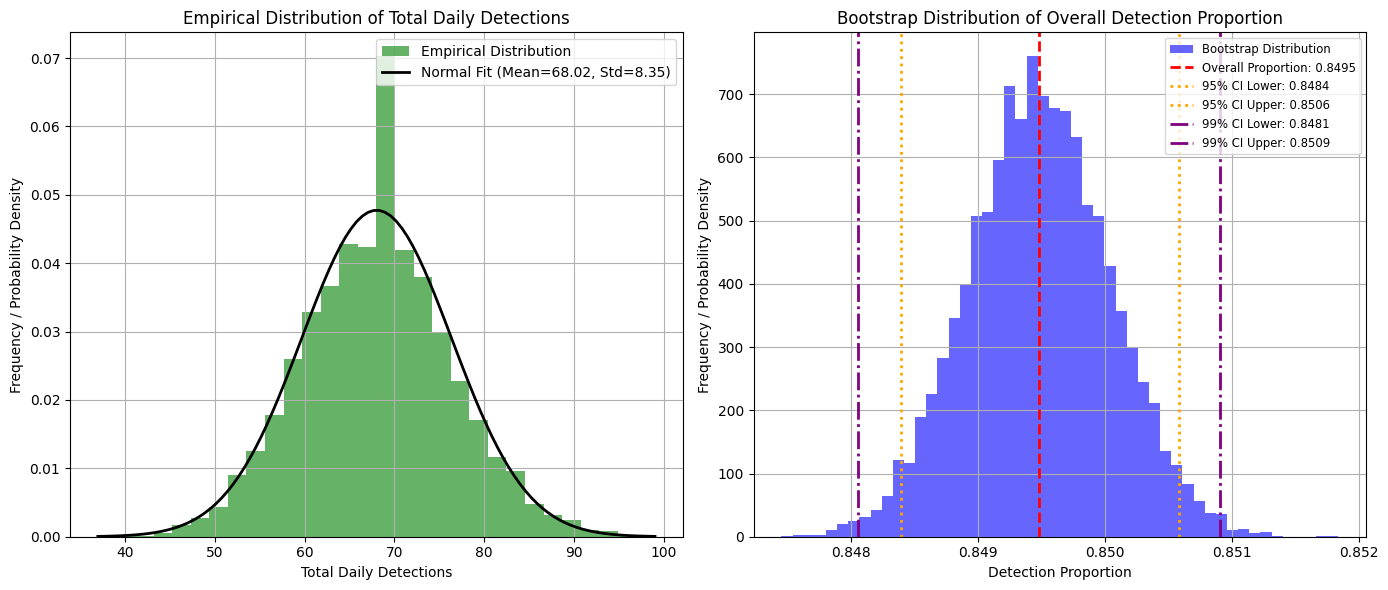

In [8]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Set up figure and axes for subplots
plt.figure(figsize=(14, 6))

# Plot 1: Empirical Distribution of Total Daily Detections vs. Normal Approximation
plt.subplot(1, 2, 1)

# Histogram of daily detected vehicles
plt.hist(daily_detected_vehicles_arr, bins=30, density=True, alpha=0.6, color='g', label='Empirical Distribution')

# Fit a Normal distribution to the daily detected vehicles data
mu, std = np.mean(daily_detected_vehicles_arr), np.std(daily_detected_vehicles_arr)
x = np.linspace(daily_detected_vehicles_arr.min(), daily_detected_vehicles_arr.max(), 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label=f'Normal Fit (Mean={mu:.2f}, Std={std:.2f})')

plt.title('Empirical Distribution of Total Daily Detections')
plt.xlabel('Total Daily Detections')
plt.ylabel('Frequency / Probability Density')
plt.legend()
plt.grid(True)

# Plot 2: Bootstrap Distribution of Overall Detection Proportion with CIs
plt.subplot(1, 2, 2)

# Histogram of bootstrap detection proportions
plt.hist(bootstrap_detection_proportions_arr, bins=50, density=True, alpha=0.6, color='b', label='Bootstrap Distribution')

# Add vertical lines for overall proportion and CIs
plt.axvline(overall_detection_proportion, color='red', linestyle='--', linewidth=2, label=f'Overall Proportion: {overall_detection_proportion:.4f}')
plt.axvline(lower_bound_95, color='orange', linestyle=':', linewidth=2, label=f'95% CI Lower: {lower_bound_95:.4f}')
plt.axvline(upper_bound_95, color='orange', linestyle=':', linewidth=2, label=f'95% CI Upper: {upper_bound_95:.4f}')
plt.axvline(lower_bound_99, color='purple', linestyle='-.', linewidth=2, label=f'99% CI Lower: {lower_bound_99:.4f}')
plt.axvline(upper_bound_99, color='purple', linestyle='-.', linewidth=2, label=f'99% CI Upper: {upper_bound_99:.4f}')

plt.title('Bootstrap Distribution of Overall Detection Proportion')
plt.xlabel('Detection Proportion')
plt.ylabel('Frequency / Probability Density')
plt.legend(fontsize='small')
plt.grid(True)

plt.tight_layout()
plt.show()


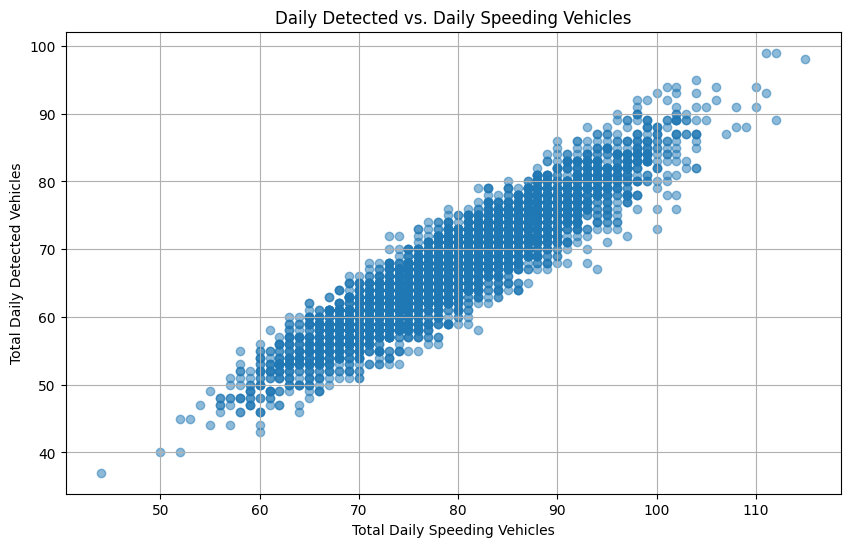

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(daily_speeding_vehicles_arr, daily_detected_vehicles_arr, alpha=0.5)
plt.title('Daily Detected vs. Daily Speeding Vehicles')
plt.xlabel('Total Daily Speeding Vehicles')
plt.ylabel('Total Daily Detected Vehicles')
plt.grid(True)
plt.show()

In [9]:
import pandas as pd

# Create a DataFrame from the simulated data
simulated_df = pd.DataFrame({
    'day': range(1, num_days + 1),
    'daily_speeding_vehicles': daily_speeding_vehicles_arr,
    'daily_detected_vehicles': daily_detected_vehicles_arr
})

# Save the DataFrame to a CSV file
csv_filename = 'simulated_traffic_data.csv'
simulated_df.to_csv(csv_filename, index=False)

print(f"Simulated data saved to {csv_filename}")
print(f"First 5 rows of the saved data:\n{simulated_df.head()}")

Simulated data saved to simulated_traffic_data.csv
First 5 rows of the saved data:
   day  daily_speeding_vehicles  daily_detected_vehicles
0    1                       75                       63
1    2                       77                       69
2    3                       98                       81
3    4                       73                       58
4    5                       85                       73


In [ ]:
print(f"First 5 daily speeding vehicles (from array): {daily_speeding_vehicles_arr[:5]}")
print(f"First 5 daily detected vehicles (from array): {daily_detected_vehicles_arr[:5]}")